# 🎮 Steam Sales Prediction
**Ziel:** Vorhersage der Anzahl Reviews (10–2000) von Indie Steam-Spielen als Proxy für Umsatz

**Team:** [Eure Namen]

**Zwischenstand:** 18. Juni 2026

## 1. Setup & Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

# Schöne Plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✅ Alle Libraries geladen!')

✅ Alle Libraries geladen!


## 2. Daten laden

In [22]:
df_raw = pd.read_csv('games.csv', on_bad_lines='skip')
df_raw = df_raw.reset_index()

df_raw = df_raw.rename(columns={
    'index': 'AppID',
    'AppID': 'Name',
    'Name': 'Release date',
    'Release date': 'Estimated owners',
    'Estimated owners': 'Peak CCU'
})

df_raw.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Peak CCU,Required age,Price,DiscountDLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


## 3. Daten-Exploration (EDA)

In [23]:
# Spaltenübersicht
print('=== Spalten im Datensatz ===')
print(df_raw.columns.tolist())
print()
print('=== Datentypen & fehlende Werte ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
info_df = pd.DataFrame({'Typ': df_raw.dtypes, 'Fehlend': missing, 'Fehlend %': missing_pct})
print(info_df[info_df['Fehlend'] > 0])

=== Spalten im Datensatz ===
['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Peak CCU', 'Required age', 'Price', 'DiscountDLC count', 'About the game', 'Supported languages', 'Full audio languages', 'Reviews', 'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

=== Datentypen & fehlende Werte ===
                    Typ  Fehlend  Fehlend %
Name                str        1        0.0
About the game      str     8449        6.9
Reviews             str   110541       90.2
Header image        str       81        0.1
Website             str    72935       59.5
Support url         str    68469       55.8
Support

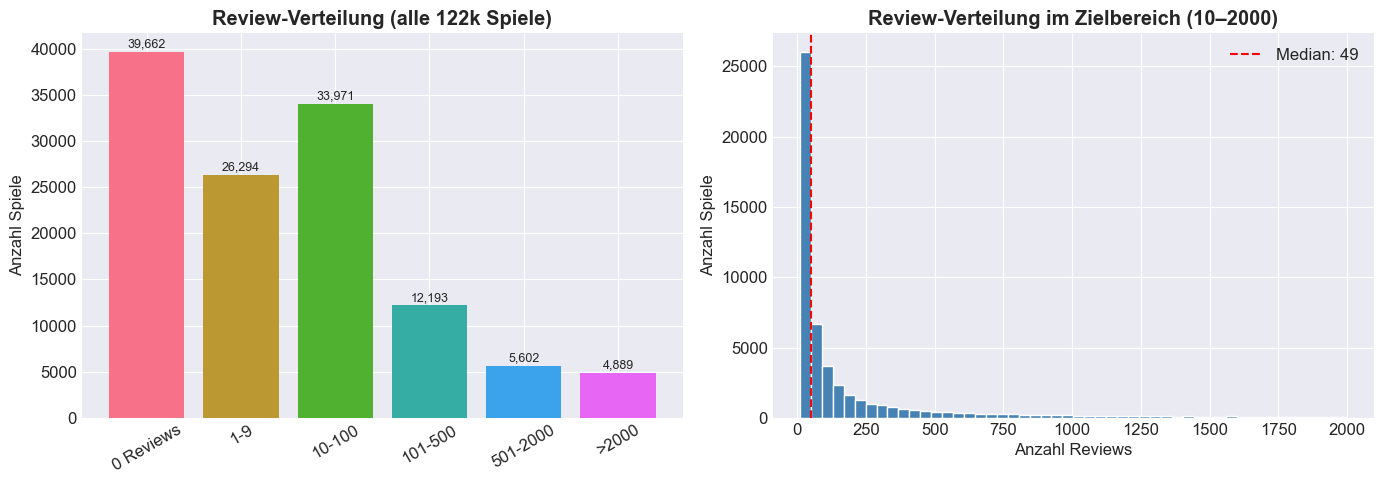

→ Verteilung ist stark rechtsschieft (typisch für Steam-Daten!)


In [24]:
# Ziel-Variable erstellen: Total Reviews
df_raw['Total_reviews'] = df_raw['Positive'] + df_raw['Negative']

# Verteilung der Reviews im gesamten Datensatz
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Alle Reviews
review_bins = [
    ('0 Reviews', (df_raw['Total_reviews'] == 0).sum()),
    ('1-9', ((df_raw['Total_reviews'] >= 1) & (df_raw['Total_reviews'] < 10)).sum()),
    ('10-100', ((df_raw['Total_reviews'] >= 10) & (df_raw['Total_reviews'] <= 100)).sum()),
    ('101-500', ((df_raw['Total_reviews'] > 100) & (df_raw['Total_reviews'] <= 500)).sum()),
    ('501-2000', ((df_raw['Total_reviews'] > 500) & (df_raw['Total_reviews'] <= 2000)).sum()),
    ('>2000', (df_raw['Total_reviews'] > 2000).sum()),
]
labels, counts = zip(*review_bins)
axes[0].bar(labels, counts, color=sns.color_palette('husl', len(labels)))
axes[0].set_title('Review-Verteilung (alle 122k Spiele)', fontweight='bold')
axes[0].set_ylabel('Anzahl Spiele')
axes[0].tick_params(axis='x', rotation=30)
for i, (l, c) in enumerate(zip(labels, counts)):
    axes[0].text(i, c + 500, f'{c:,}', ha='center', fontsize=9)

# Nur im Zielbereich
target = df_raw[(df_raw['Total_reviews'] >= 10) & (df_raw['Total_reviews'] <= 2000)]
axes[1].hist(target['Total_reviews'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Review-Verteilung im Zielbereich (10–2000)', fontweight='bold')
axes[1].set_xlabel('Anzahl Reviews')
axes[1].set_ylabel('Anzahl Spiele')
axes[1].axvline(target['Total_reviews'].median(), color='red', linestyle='--', label=f'Median: {target["Total_reviews"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_review_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Verteilung ist stark rechtsschieft (typisch für Steam-Daten!)')

## 4. Datensatz filtern (Indie, bezahlt, 10–2000 Reviews)

In [25]:
# Filter anwenden
indie_mask   = df_raw['Tags'].str.contains('Indie', na=False)
paid_mask    = df_raw['Price'] > 0
reviews_mask = (df_raw['Total_reviews'] >= 10) & (df_raw['Total_reviews'] <= 2000)

df = df_raw[indie_mask & paid_mask & reviews_mask].copy()
df = df.reset_index(drop=True)

print(f'✅ Gefilterte Spiele: {len(df):,}')
print()
print('=== Ziel-Variable: Total Reviews ===')
print(df['Total_reviews'].describe().round(1))

✅ Gefilterte Spiele: 13,060

=== Ziel-Variable: Total Reviews ===
count    13060.0
mean       227.8
std        366.0
min         10.0
25%         25.0
50%         68.0
75%        245.0
max       1998.0
Name: Total_reviews, dtype: float64


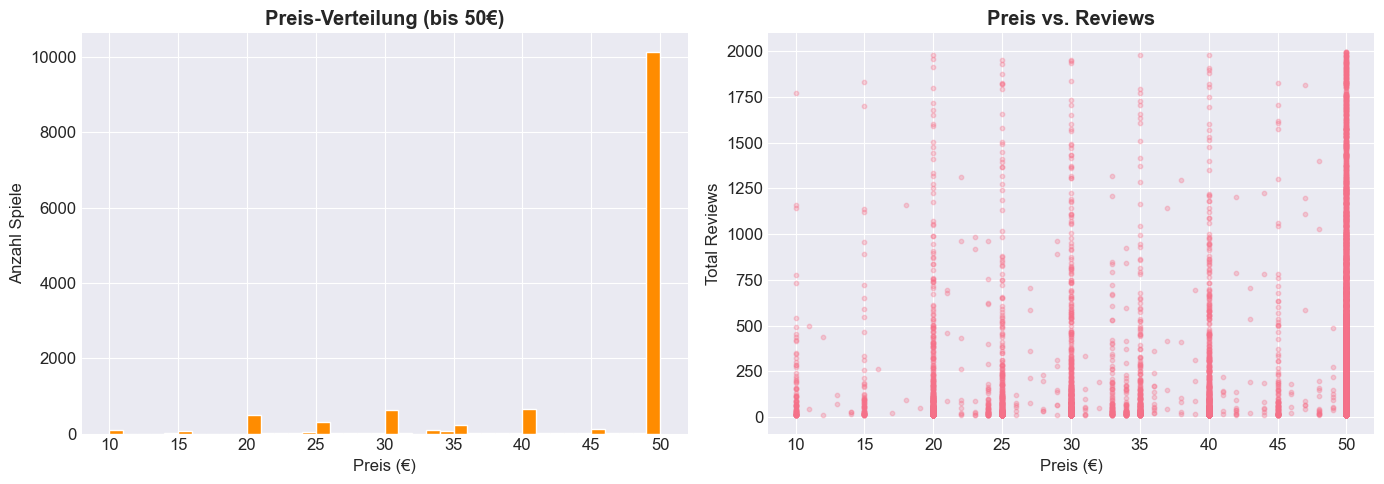

In [26]:
# Preis-Verteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Price'].clip(upper=50), bins=40, color='darkorange', edgecolor='white')
axes[0].set_title('Preis-Verteilung (bis 50€)', fontweight='bold')
axes[0].set_xlabel('Preis (€)')
axes[0].set_ylabel('Anzahl Spiele')

# Reviews vs Preis
axes[1].scatter(df['Price'].clip(upper=50), df['Total_reviews'], alpha=0.3, s=10)
axes[1].set_title('Preis vs. Reviews', fontweight='bold')
axes[1].set_xlabel('Preis (€)')
axes[1].set_ylabel('Total Reviews')

plt.tight_layout()
plt.savefig('plot_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

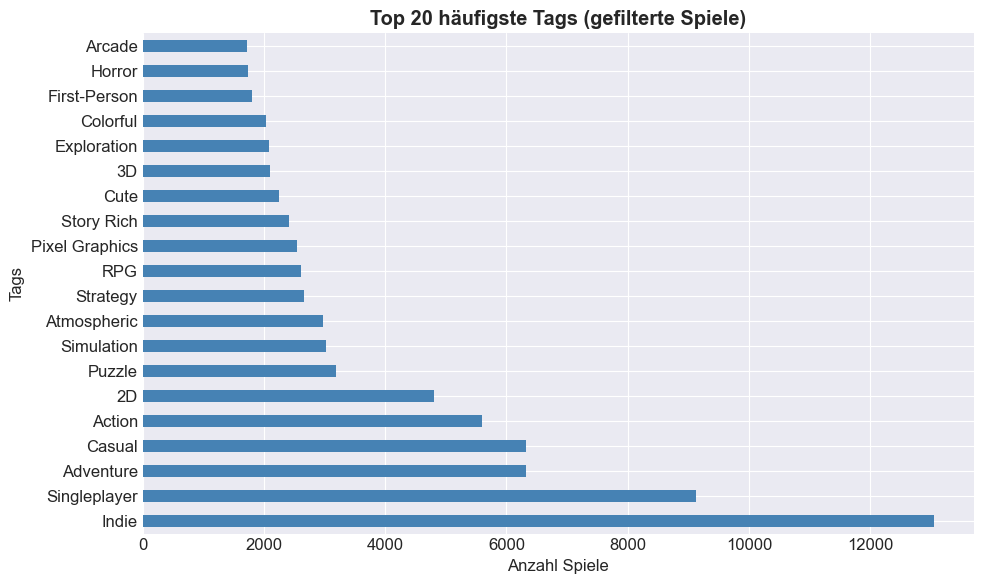

In [27]:
# Top Tags
all_tags = df['Tags'].dropna().str.split(',').explode().str.strip()
top_tags = all_tags.value_counts().head(20)

plt.figure(figsize=(10, 6))
top_tags.plot(kind='barh', color='steelblue')
plt.title('Top 20 häufigste Tags (gefilterte Spiele)', fontweight='bold')
plt.xlabel('Anzahl Spiele')
plt.tight_layout()
plt.savefig('plot_top_tags.png', dpi=150, bbox_inches='tight')
plt.show()

Release_year
2010.0     408.0
2011.0     836.0
2012.0    1110.0
2013.0    1091.0
2014.0     314.0
2015.0     155.0
2016.0      87.0
2017.0      39.0
2018.0      27.0
2019.0      19.0
2020.0      18.0
2021.0      10.0
2022.0       6.0
2023.0       4.0
2024.0       3.0
2025.0       0.0
Name: Total_reviews, dtype: float64


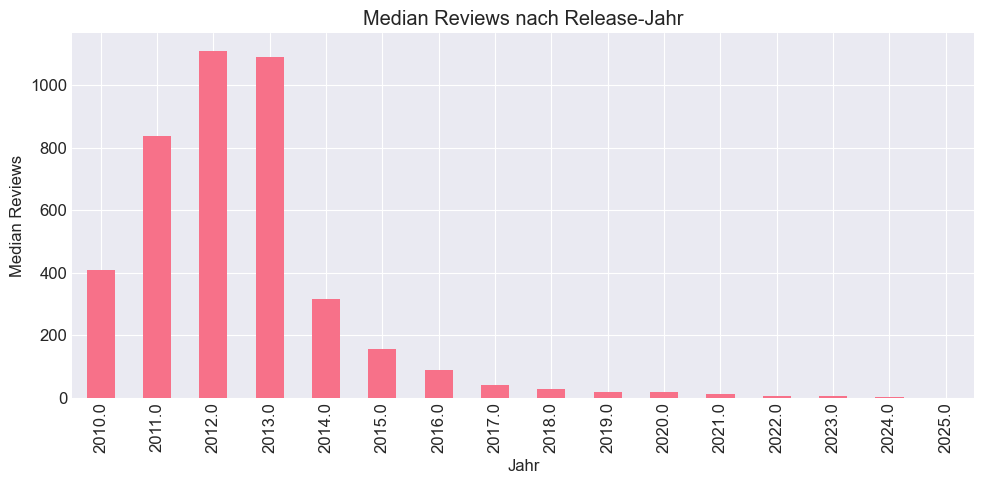

In [28]:
df_raw['Total_reviews'] = df_raw['Positive'] + df_raw['Negative']
df_raw['Release_year'] = df_raw['Release date'].astype(str).str.extract(r'(\d{4})').astype(float)

yearly = df_raw.groupby('Release_year')['Total_reviews'].median().dropna()
yearly = yearly[(yearly.index >= 2010) & (yearly.index <= 2025)]

print(yearly)

plt.figure(figsize=(10, 5))
yearly.plot(kind='bar')
plt.title('Median Reviews nach Release-Jahr')
plt.xlabel('Jahr')
plt.ylabel('Median Reviews')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [29]:
# Text-Features kombinieren
df['text_combined'] = (
    df['About the game'].fillna('') + ' ' +
    df['Tags'].fillna('') + ' ' +
    df['Genres'].fillna('') + ' ' +
    df['Categories'].fillna('')
)

# Numerische Features
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').fillna(0)
df['Has_achievements'] = (df['Achievements'] > 0).astype(int)
df['Num_tags'] = df['Tags'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
df['Desc_length'] = df['About the game'].fillna('').apply(len)
df['Is_windows'] = df['Windows'].astype(str).str.lower().eq('true').astype(int)
df['Is_mac'] = df['Mac'].astype(str).str.lower().eq('true').astype(int)
df['Is_linux'] = df['Linux'].astype(str).str.lower().eq('true').astype(int)
df['Release_year'] = pd.to_datetime(df['Release date'], errors='coerce').dt.year.fillna(2020)

numeric_features = ['Price', 'Has_achievements', 'Num_tags', 'Desc_length',
                    'Is_windows', 'Is_mac', 'Is_linux', 'Release_year']

print('✅ Features erstellt:')
print(df[numeric_features].describe().round(2))

✅ Features erstellt:
          Price  Has_achievements  Num_tags  Desc_length  Is_windows  \
count  13060.00          13060.00  13060.00     13060.00     13060.0   
mean      59.78              0.74     14.54      1304.13         1.0   
std       20.96              0.44      5.79       892.63         0.0   
min       10.00              0.00      1.00         0.00         1.0   
25%       50.00              0.00     10.00       698.00         1.0   
50%       60.00              1.00     16.00      1104.00         1.0   
75%       80.00              1.00     20.00      1654.00         1.0   
max      100.00              1.00     20.00     15087.00         1.0   

         Is_mac  Is_linux  Release_year  
count  13060.00  13060.00      13060.00  
mean       0.27      0.19       2019.95  
std        0.44      0.39          3.33  
min        0.00      0.00       1997.00  
25%        0.00      0.00       2017.00  
50%        0.00      0.00       2020.00  
75%        1.00      0.00       2023

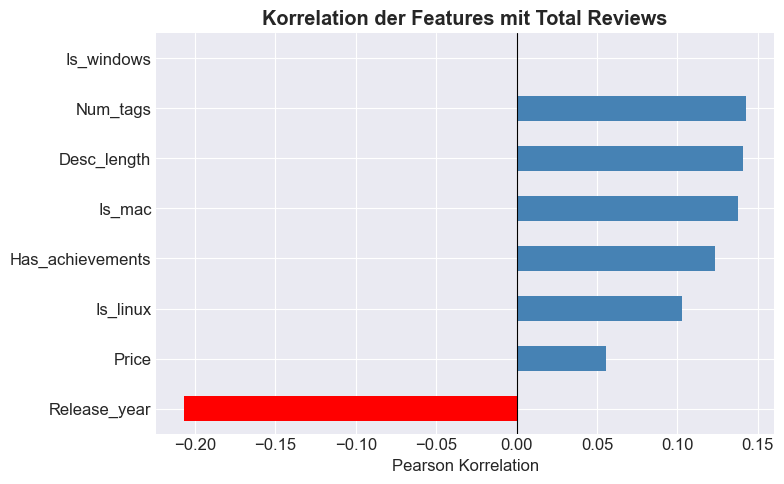

In [30]:
# Korrelation numerischer Features mit Ziel
corr_data = df[numeric_features + ['Total_reviews']].corr()['Total_reviews'].drop('Total_reviews').sort_values()

plt.figure(figsize=(8, 5))
colors = ['red' if x < 0 else 'steelblue' for x in corr_data]
corr_data.plot(kind='barh', color=colors)
plt.title('Korrelation der Features mit Total Reviews', fontweight='bold')
plt.xlabel('Pearson Korrelation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('plot_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Baseline Modell: XGBoost (Text + Tags)

In [31]:
# Ziel-Variable: log-transformiert (wegen schiefer Verteilung)
y = np.log1p(df['Total_reviews'])

# TF-IDF auf kombinierten Text
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3)
X_text = tfidf.fit_transform(df['text_combined'])

# Numerische Features
X_num = df[numeric_features].values

# Alles kombinieren
from scipy.sparse import hstack, csr_matrix
X = hstack([X_text, csr_matrix(X_num)])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training: {X_train.shape[0]:,} Spiele')
print(f'Test:     {X_test.shape[0]:,} Spiele')
print(f'Features: {X_train.shape[1]:,}')

Training: 10,448 Spiele
Test:     2,612 Spiele
Features: 3,008


In [32]:
# XGBoost trainieren
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist'  # schneller
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
print('✅ Training abgeschlossen!')

[0]	validation_0-rmse:1.38186
[50]	validation_0-rmse:1.14955
[100]	validation_0-rmse:1.14249
[150]	validation_0-rmse:1.14199
[200]	validation_0-rmse:1.14271
[250]	validation_0-rmse:1.14347
[299]	validation_0-rmse:1.14349
✅ Training abgeschlossen!


In [33]:
# Evaluation
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)       # zurück in echte Reviews
y_true = np.expm1(y_test.values)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print('=== Modell-Performance (Baseline XGBoost) ===')
print(f'MAE:  {mae:.1f} Reviews')
print(f'RMSE: {rmse:.1f} Reviews')
print(f'R²:   {r2:.3f}')
print()
print('Interpretation: Das Modell liegt im Schnitt um ~{:.0f} Reviews daneben.'.format(mae))

=== Modell-Performance (Baseline XGBoost) ===
MAE:  162.6 Reviews
RMSE: 334.1 Reviews
R²:   0.151

Interpretation: Das Modell liegt im Schnitt um ~163 Reviews daneben.


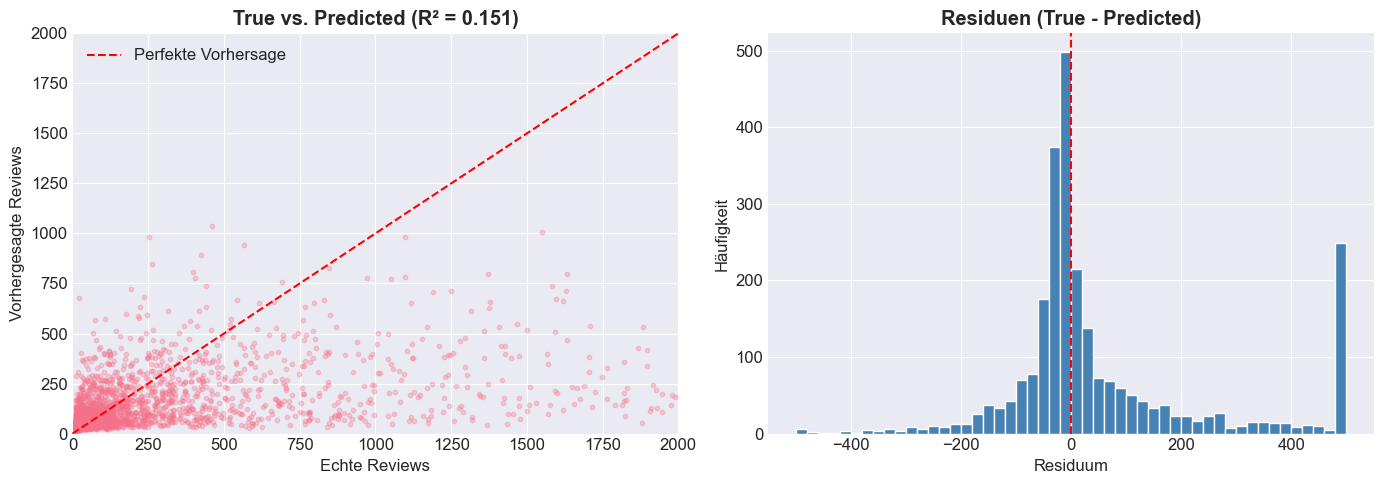

In [34]:
# Prediction vs. True Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: True vs Predicted
axes[0].scatter(y_true, y_pred, alpha=0.3, s=10)
axes[0].plot([0, 2000], [0, 2000], 'r--', label='Perfekte Vorhersage')
axes[0].set_xlabel('Echte Reviews')
axes[0].set_ylabel('Vorhergesagte Reviews')
axes[0].set_title(f'True vs. Predicted (R² = {r2:.3f})', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 2000)
axes[0].set_ylim(0, 2000)

# Residuen
residuals = y_true - y_pred
axes[1].hist(residuals.clip(-500, 500), bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuen (True - Predicted)', fontweight='bold')
axes[1].set_xlabel('Residuum')
axes[1].set_ylabel('Häufigkeit')

plt.tight_layout()
plt.savefig('plot_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

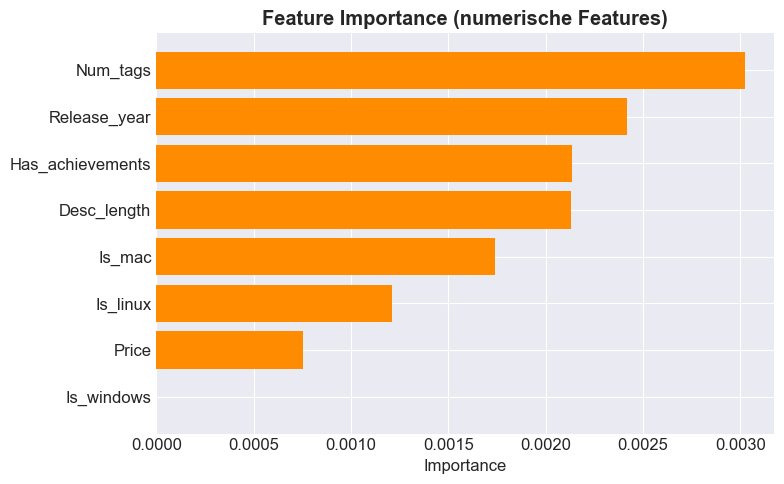

Top TF-IDF Terme:
  trading cards: 0.0303
  steam trading: 0.0292
  steam cloud: 0.0036
  sound effects: 0.0033
  craft: 0.0028
  sexual content: 0.0027
  trading: 0.0027
  online co: 0.0026
  great soundtrack: 0.0025
  check: 0.0024
  sandbox: 0.0024
  own unique: 0.0022
  sexual: 0.0019
  play on: 0.0018
  early access: 0.0018


In [35]:
# Feature Importance
importance = model.feature_importances_

# Nur numerische Features (letzten 8)
num_importance = importance[-len(numeric_features):]
fi_df = pd.DataFrame({'Feature': numeric_features, 'Importance': num_importance})
fi_df = fi_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='darkorange')
plt.title('Feature Importance (numerische Features)', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top TF-IDF Terme:')
tfidf_imp = importance[:len(tfidf.get_feature_names_out())]
top_idx = np.argsort(tfidf_imp)[-15:]
for i in top_idx[::-1]:
    print(f'  {tfidf.get_feature_names_out()[i]}: {tfidf_imp[i]:.4f}')

## 7. Zusammenfassung für Präsentation

In [36]:
print('=' * 60)
print('    STEAM SALES PREDICTION – ZWISCHENSTAND')
print('=' * 60)
print()
print('📦 DATENSATZ')
print(f'   Gesamt:          {len(df_raw):>8,} Spiele')
print(f'   Nach Filter:     {len(df):>8,} Spiele (Indie, paid, 10–2000 Reviews)')
print(f'   Spalten:         {df_raw.shape[1]:>8}')
print()
print('🎯 ZIEL-VARIABLE: Total Reviews')
print(f'   Min:             {df["Total_reviews"].min():>8.0f}')
print(f'   Median:          {df["Total_reviews"].median():>8.0f}')
print(f'   Max:             {df["Total_reviews"].max():>8.0f}')
print(f'   Verteilung:      stark rechtsschieft')
print()
print('🤖 BASELINE MODELL: XGBoost + TF-IDF')
print(f'   Features:        Text (TF-IDF) + Tags + Numerisch')
print(f'   MAE:             {mae:>8.1f} Reviews')
print(f'   RMSE:            {rmse:>8.1f} Reviews')
print(f'   R²:              {r2:>8.3f}')
print()
print('🔜 NÄCHSTE SCHRITTE')
print('   → Fine-tuned BERT / DistilBERT auf Beschreibungen')
print('   → Vergleich Baseline vs. BERT')
print('   → Web-App mit Streamlit bauen')
print('=' * 60)

    STEAM SALES PREDICTION – ZWISCHENSTAND

📦 DATENSATZ
   Gesamt:           122,611 Spiele
   Nach Filter:       13,060 Spiele (Indie, paid, 10–2000 Reviews)
   Spalten:               42

🎯 ZIEL-VARIABLE: Total Reviews
   Min:                   10
   Median:                68
   Max:                 1998
   Verteilung:      stark rechtsschieft

🤖 BASELINE MODELL: XGBoost + TF-IDF
   Features:        Text (TF-IDF) + Tags + Numerisch
   MAE:                162.6 Reviews
   RMSE:               334.1 Reviews
   R²:                 0.151

🔜 NÄCHSTE SCHRITTE
   → Fine-tuned BERT / DistilBERT auf Beschreibungen
   → Vergleich Baseline vs. BERT
   → Web-App mit Streamlit bauen


## 8. Einzelnes Spiel vorhersagen (Demo)

In [37]:
def predict_reviews(description, tags, price=10.0, year=2024):
    """Vorhersage für ein neues Spiel"""
    text = f"{description} {tags} Indie"
    X_t = tfidf.transform([text])
    X_n = csr_matrix([[price, 0, len(tags.split(',')), len(description),
                        1, 0, 0, year]])
    X_input = hstack([X_t, X_n])
    pred = np.expm1(model.predict(X_input)[0])
    return round(pred)

# Beispiel-Vorhersagen
beispiele = [
    {
        'description': 'A dark atmospheric horror game with puzzle solving and survival mechanics.',
        'tags': 'Horror,Survival,Atmospheric,Dark,Puzzle,Indie,Singleplayer',
        'price': 14.99
    },
    {
        'description': 'A colorful casual 2D platformer with cute characters and simple controls for all ages.',
        'tags': 'Casual,Platformer,Colorful,Family Friendly,2D,Cute,Indie',
        'price': 4.99
    },
    {
        'description': 'Deep turn-based strategy RPG with complex systems, base building, and epic battles.',
        'tags': 'Strategy,RPG,Turn-Based,Base Building,Tactical,Deep,Indie',
        'price': 19.99
    },
]

print('=== Demo: Vorhersagen für neue Spiele ===')
for b in beispiele:
    pred = predict_reviews(b['description'], b['tags'], b['price'])
    print(f"  Genre: {b['tags'].split(',')[0]:20s} | Preis: {b['price']:5.2f}€ | Vorhergesagte Reviews: {pred:,}")

=== Demo: Vorhersagen für neue Spiele ===
  Genre: Horror               | Preis: 14.99€ | Vorhergesagte Reviews: 34
  Genre: Casual               | Preis:  4.99€ | Vorhergesagte Reviews: 35
  Genre: Strategy             | Preis: 19.99€ | Vorhergesagte Reviews: 60
